# 11 二分查找

## 11.1 搜索插入位置

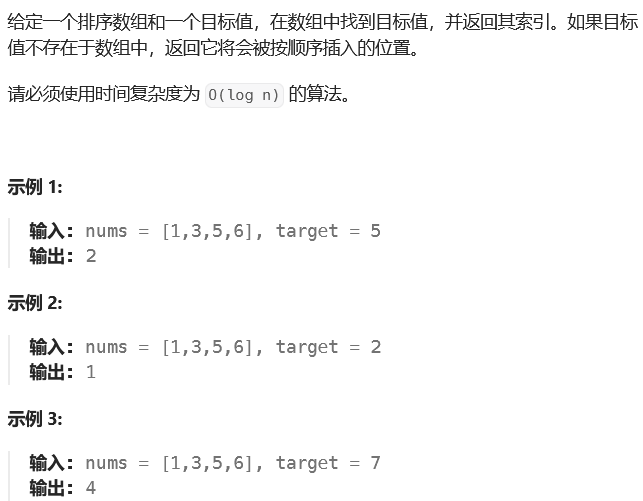

In [ ]:
class Solution:
    def searchInsert(self, nums: List[int], target: int) -> int:
        left = 0
        right = len(nums) - 1
        
        while left <= right:
            # 防止整数溢出（Python无需担心，但面试标准写法）
            mid = left + (right - left) // 2
            if nums[mid] == target:
                return mid
            elif nums[mid] < target:
                # 目标在右侧，缩小左边界
                left = mid + 1
            else:
                # 目标在左侧，缩小右边界
                right = mid - 1
        # 循环结束，left就是插入位置，跳出循环时一定满足：left = right + 1
        return left
# left：第一个大于 target 的下标，正好是插入位置
# right：最后一个小于 target 的下标，比插入位置少 1

## 11.2 搜索二维矩阵

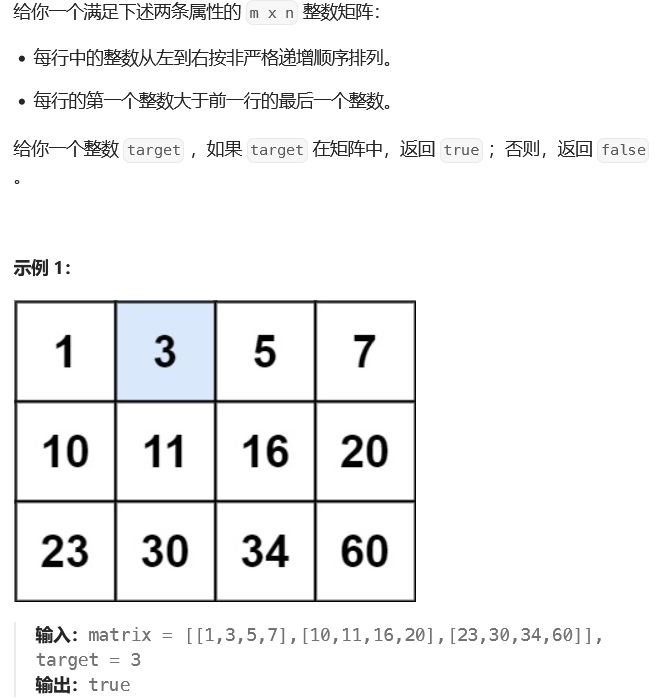

In [ ]:
class Solution:
    def searchMatrix(self, matrix: List[List[int]], target: int) -> bool:
        m = len(matrix)
        n = len(matrix[0])
        left = 0
        right = m * n - 1
        
        while left <= right:
            mid = left + (right - left) // 2
            x = mid // n
            y = mid % n
            if matrix[x][y] == target:
                return True
            elif matrix[x][y] < target:
                left = mid + 1
            else:
                right = mid - 1
        return False

## 11.3 在排序数组中查找元素的第一个和最后一个位置

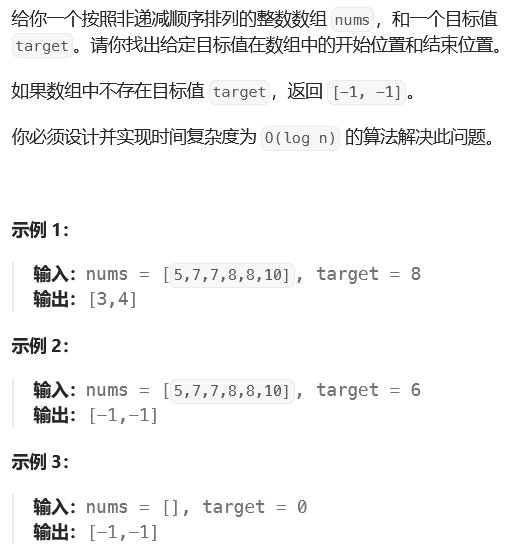

In [ ]:
class Solution:
    def searchRange(self, nums: List[int], target: int) -> List[int]:
        # 找左边界：第一个等于target的位置
        def find_left():
            l, r = 0, len(nums) - 1
            left_idx = -1
            while l <= r:
                mid = (l + r) // 2
                if nums[mid] == target:
                    left_idx = mid  # 记录当前位置，继续往左搜更小下标
                    r = mid - 1
                elif nums[mid] < target:
                    l = mid + 1
                else:
                    r = mid - 1
            return left_idx
        
        # 找右边界：最后一个等于target的位置
        def find_right():
            l, r = 0, len(nums) - 1
            right_idx = -1
            while l <= r:
                mid = (l + r) // 2
                if nums[mid] == target:
                    right_idx = mid  # 记录当前位置，继续往右搜更大下标
                    l = mid + 1
                elif nums[mid] < target:
                    l = mid + 1
                else:
                    r = mid - 1
            return right_idx
        
        left = find_left()
        # 左边界为-1说明不存在target，直接返回
        if left == -1:
            return [-1, -1]
        right = find_right()
        return [left, right]

## 11.4 搜索旋转排序数组

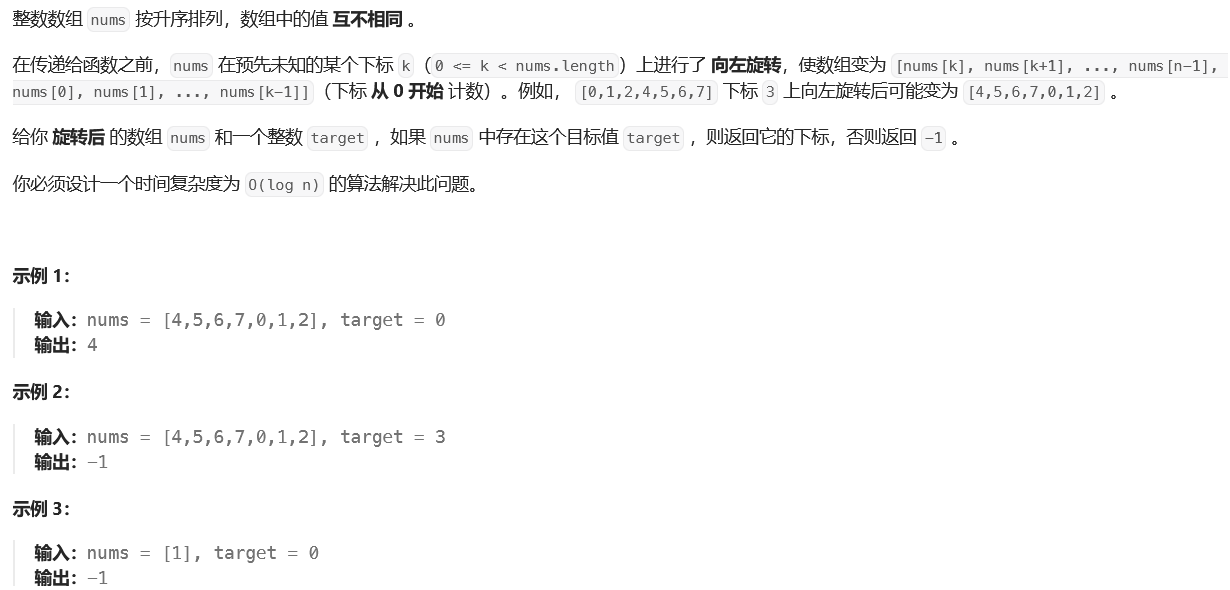

In [ ]:
class Solution:
    def search(self, nums: List[int], target: int) -> int:
        l, r = 0, len(nums) - 1
        while l <= r:
            mid = l + (r - l) // 2  # 防止溢出，规范写法
            if nums[mid] == target:
                return mid
            # 左半段 [l, mid] 有序
            if nums[l] <= nums[mid]:
                # target 在左有序区间内
                if nums[l] <= target < nums[mid]:
                    r = mid - 1
                else:
                    l = mid + 1
            # 右半段 [mid, r] 有序
            else:
                if nums[mid] < target <= nums[r]:
                    l = mid + 1
                else:
                    r = mid - 1
        # 循环结束没找到
        return -1

## 11.5 寻找旋转排序数组中的最小值

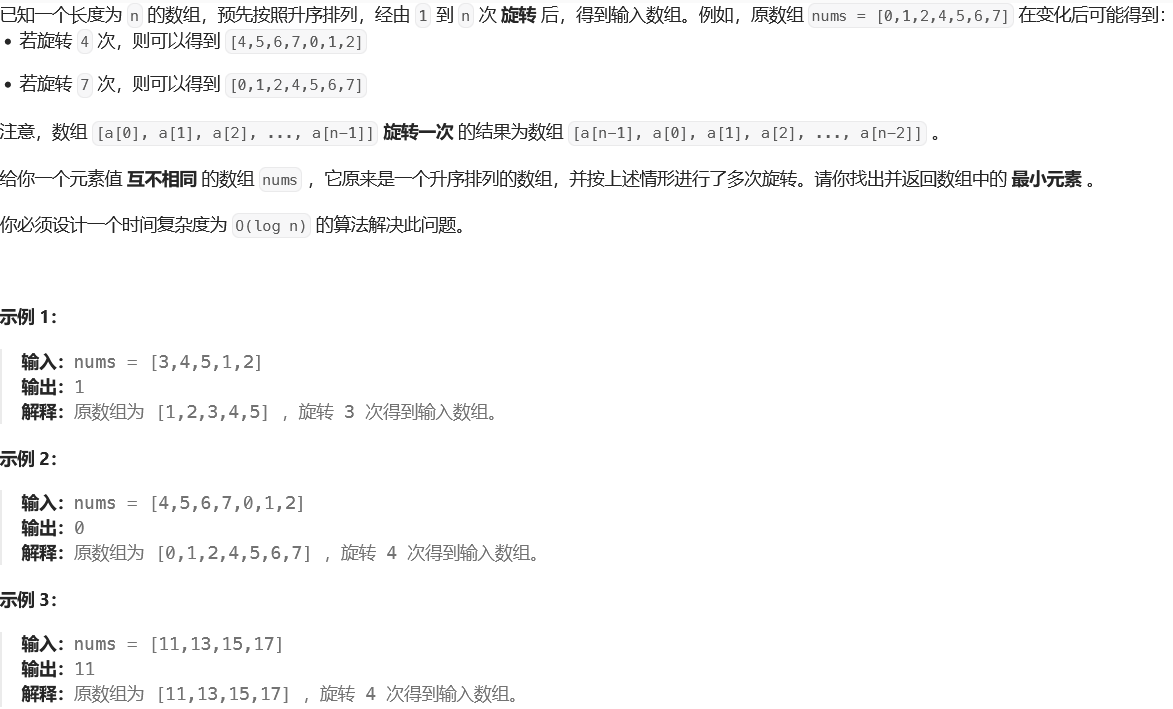

In [ ]:
class Solution:
    def findMin(self, nums: List[int]) -> int:
        left = 0
        right = len(nums) - 1
        while left < right:
            mid = (left + right) // 2
            if nums[mid] > nums[right]:
                # 最小值在右边
                left = mid + 1
            else:
                # 最小值在左边（含mid）
                right = mid
        return nums[left]

## 11.6 寻找两个正序数组的中位数

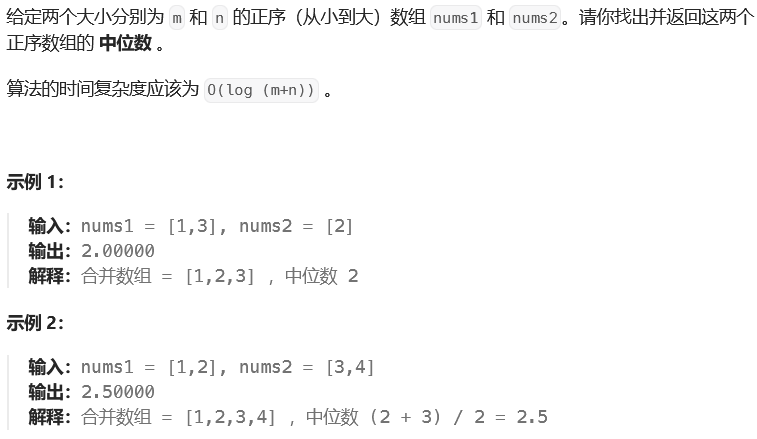

In [ ]:
class Solution:
    def findMedianSortedArrays(self, nums1: List[int], nums2: List[int]) -> float:
        # 保证 nums1 是更短数组，减少二分次数
        if len(nums1) > len(nums2):
            nums1, nums2 = nums2, nums1
        m, n = len(nums1), len(nums2)
        l, r = 0, m
        total_left = (m + n + 1) // 2  # 左半总元素个数

        while l <= r:
            i = (l + r) // 2    # nums1 左边i个
            j = total_left - i  # nums2 左边j个

            # 边界赋值
            nums1_left = nums1[i-1] if i > 0 else float("-inf")
            nums1_right = nums1[i] if i < m else float("inf")
            nums2_left = nums2[j-1] if j > 0 else float("-inf")
            nums2_right = nums2[j] if j < n else float("inf")

            if nums1_left > nums2_right:
                # nums1左边太大，切往左移
                r = i - 1
            elif nums2_left > nums1_right:
                # nums1左边太小，切往右移
                l = i + 1
            else:
                # 合法切割，计算中位数
                if (m + n) % 2 == 1:
                    return max(nums1_left, nums2_left)
                else:
                    return (max(nums1_left, nums2_left) + min(nums1_right, nums2_right)) / 2
        return 0.0